In [31]:
# Prior to running this notebook, you MAY want to update all the google sheets with data.  Currently, this is implemented as
# a command on Gareth's laptop:
!source ~/.zshrc; bee_scraper

/Users/garethhouk/.virtualenvs/QueenBee-BFuRxLbU/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
fetching data for date 2025-12-28 00:00:00
fetching data for date 2025-12-29 00:00:00
fetching data for date 2025-12-30 00:00:00


In [32]:
from src.bee_classes import Word,SolutionList,Puzzle,NytBee_Parameters,BeeParameters,Sbsolver_Parameters,NytBee_Solution,Sbsolver_Solution,Bee_DataBase
from src.google_sheet_classes import Google_Sheet
from dataclasses import dataclass, field
import pandas as pd
from datetime import datetime, timedelta
import os
import math
import copy
import random

def unmatched_words(x,col_label_wordset,col_label_wordsubset):
    if isinstance(x[col_label_wordsubset],float):
        set_wordsubset = set()
    else:
        set_wordsubset = set([w for w in x[col_label_wordsubset].split(' ') if len(w)>0])
    set_wordset = set([w for w in x[col_label_wordset].split(' ') if len(w)>0])
    output = ' '.join(sorted(list(set_wordsubset.difference(set_wordset))))
    if len(output)>0:
        print(f'Warning! Unmatched missed words\n\n {x}')
    return output

class MissedWords_Parameters:
    date = 'date'
    missed_words = 'missed words'
    notes = 'notes'
    solution = 'solution'
    unmatched_words = 'unmatched words'

@dataclass
class Bee_MissedWords:
    google_sheet_id: str = None
    google_sheet_name: str = None
    google_sheet: Google_Sheet = None
    start_date: str = None 
    end_date: str = None
    missing_datetimes_list = None
    local: bool = False
    timestampstr = None
    df = None

    def __post_init__(self):
        self.google_sheet = Google_Sheet(google_sheet_name=self.google_sheet_name,google_sheet_id=self.google_sheet_id)
        self.google_sheet.open_by_id()
        self.google_sheet.read_to_df()
        self.google_sheet_name = self.google_sheet.google_sheet_name
        self.google_sheet_id = self.google_sheet.google_sheet_id
        self.df = self.google_sheet.df
        if len(self.df)==0:
            print('Current bee missing words sheet is empty')
        else:
            if self.local:
                self.timestampstr = self.timestamp()
                self.write_db_to_local(final=False)
            self.validate()

    def __str__(self):
        return f'Bee_MissedWords for "{self.google_sheet_name}" "{self.google_sheet_id}"\n start:end date {self.start_date}:{self.end_date}\n{self.df}'

    def validate(self):
        df = pd.DataFrame({MissedWords_Parameters.date: pd.Series(dtype='str'),
                            MissedWords_Parameters.missed_words: pd.Series(dtype='str'),
                            MissedWords_Parameters.notes: pd.Series(dtype='str'),
                            MissedWords_Parameters.solution: pd.Series(dtype='str'),
                            })

        for _,row in self.df.iterrows():
            try:
                date = pd.to_datetime(row[MissedWords_Parameters.date])
                date_str = date.strftime(Puzzle.date_format)
                missed_words = [w for w in row[MissedWords_Parameters.missed_words].split(' ') if len(w)>0]
                notes = row[MissedWords_Parameters.notes]
                if len(missed_words)==1 and missed_words[0]=="":
                    solution = None
                else:
                    solution = SolutionList(missed_words).make_list_to_string()
                d = {MissedWords_Parameters.date: [date_str], MissedWords_Parameters.notes:[notes], 
                     MissedWords_Parameters.missed_words:[missed_words],
                     MissedWords_Parameters.solution: [solution],}
                df = pd.concat([df, pd.DataFrame.from_dict(d, orient='columns')],  ignore_index=False, axis=0)
            except:
                print(f'Error validating Missing_Words {row[MissedWords_Parameters.date]} {row[MissedWords_Parameters.missed_words]}')
        self.df = df.sort_values(by=MissedWords_Parameters.date,ascending=True)
        self.start_date=self.df[MissedWords_Parameters.date].values[0]
        self.end_date=self.df[MissedWords_Parameters.date].values[-1]
        self.missing_datetimes_list = self.missing_datetimes()
        if len(self.missing_datetimes_list)>0:
            print(f'Missing_Words Validation WARNING: missing dates\n')
            for d in self.missing_datetimes_list:
                print(d)


    def merge_missing_words_with_db(self,df_db):
        self.df_merged = df_db.merge(self.df,how='inner',on=MissedWords_Parameters.date,suffixes=('_db', '_mw'))
        self.df_merged[MissedWords_Parameters.unmatched_words] = self.df_merged.apply(lambda x: unmatched_words(x, col_label_wordset=MissedWords_Parameters.solution+'_db', col_label_wordsubset=MissedWords_Parameters.solution+'_mw'), axis=1)

    def write_db_to_local(self,final):        
        if final:
            local_file = f'data/{self.google_sheet_name}-{self.timestampstr}.csv'
        else:
            local_file = f'data/{self.google_sheet_name}-{self.timestampstr}-BCK.csv'
        self.df.to_csv(local_file,index=False)

    def timestamp(self):
        return datetime.now().strftime("%Y-%m-%d-%H%M%S")

    def make_datestr_list(self):
        if len(self.df)>0:
            return list(self.df['date'])

    def make_datetime_list(self):
        if len(self.df)>0:
            return list(pd.to_datetime(self.df['date']))
        else:
            return []
        
    def update_df(self,df):
        self.df = df
        self.validate()

    def missing_datetimes(self):
        delta = timedelta(days=1)
        d_list = []
        d = datetime.strptime(self.start_date, Puzzle.date_format)
        while d <= datetime.strptime(self.end_date, Puzzle.date_format):
            d_list.append(d)
            d+=delta
        d_list = [d.strftime(Puzzle.date_format) for d in d_list]
        d_list = sorted(list(set(d_list)-set(self.df['date'])))
        return d_list
    
class LastWords_Parameters:
    date = 'date'
    last_words = 'lastwords'  # Changed from 'last words' to 'lastwords'
    notes = 'notes'
    solution = 'solution'
    unmatched_words = 'unmatched words'

@dataclass
class Bee_LastWords:
    google_sheet_id: str = None
    google_sheet_name: str = None
    google_sheet: Google_Sheet = None
    start_date: str = None 
    end_date: str = None
    missing_datetimes_list = None
    local: bool = False
    timestampstr = None
    df = None

    def __post_init__(self):
        self.google_sheet = Google_Sheet(google_sheet_name=self.google_sheet_name, google_sheet_id=self.google_sheet_id)
        self.google_sheet.open_by_id()
        self.google_sheet.read_to_df()
        self.google_sheet_name = self.google_sheet.google_sheet_name
        self.google_sheet_id = self.google_sheet.google_sheet_id
        self.df = self.google_sheet.df
        if len(self.df)==0:
            print('Current bee last words sheet is empty')
        else:
            if self.local:
                self.timestampstr = self.timestamp()
                self.write_db_to_local(final=False)
            self.validate()

    def validate(self):
        df = pd.DataFrame({LastWords_Parameters.date: pd.Series(dtype='str'),
                            LastWords_Parameters.last_words: pd.Series(dtype='str'),
                            LastWords_Parameters.notes: pd.Series(dtype='str'),
                            LastWords_Parameters.solution: pd.Series(dtype='str'),
                            })

        for _,row in self.df.iterrows():
            try:
                date = pd.to_datetime(row[LastWords_Parameters.date])
                date_str = date.strftime(Puzzle.date_format)
                last_words_str = row[LastWords_Parameters.last_words] if pd.notna(row[LastWords_Parameters.last_words]) else ''
                last_words = [w for w in last_words_str.split(' ') if len(w)>0]
                
                # Handle notes column if it doesn't exist
                notes = row.get('notes', '') if 'notes' in row.index else ''
                
                if len(last_words) == 0:
                    solution = None
                else:
                    solution = SolutionList(last_words).make_list_to_string()
                    
                d = {LastWords_Parameters.date: [date_str], 
                     LastWords_Parameters.notes: [notes], 
                     LastWords_Parameters.last_words: [last_words],
                     LastWords_Parameters.solution: [solution],}
                df = pd.concat([df, pd.DataFrame.from_dict(d, orient='columns')], ignore_index=False, axis=0)
            except Exception as e:
                print(f'Error validating Last_Words {row.get(LastWords_Parameters.date, "unknown")} {row.get(LastWords_Parameters.last_words, "unknown")}: {e}')
        
        if len(df) > 0:
            self.df = df.sort_values(by=LastWords_Parameters.date, ascending=True)
            self.start_date = self.df[LastWords_Parameters.date].values[0]
            self.end_date = self.df[LastWords_Parameters.date].values[-1]
        
    def timestamp(self):
        return datetime.now().strftime("%Y-%m-%d-%H%M%S")
    
    def write_db_to_local(self, final):        
        if final:
            local_file = f'data/{self.google_sheet_name}-{self.timestampstr}.csv'
        else:
            local_file = f'data/{self.google_sheet_name}-{self.timestampstr}-BCK.csv'
        self.df.to_csv(local_file, index=False)




### Stop here prior to database fetch

In [33]:
import time

prompt = None
while prompt != 'L' and prompt !='W':
    prompt = input("Read data from Local (L) or Read from Web (W)?")
    if prompt == 'W':
        # cell_start = time.time()
        
        # get missed words database
        # print("\n📊 Loading missed words sheet...")
        # mw_start = time.time()
        mw_google_sheet_id = os.environ.get('GOOGLE_SHEET_QB_MISSEDWORDS')
        mw_google_sheet = Bee_MissedWords(google_sheet_id=mw_google_sheet_id,local=False)
        # print(f"✅ Missed words total: {time.time() - mw_start:.2f}s\n")

        # get solutions database
        # print("📊 Loading solutions database...")
        # db_start = time.time()
        google_sheet_id = os.environ.get('GOOGLE_SHEET_QBDB')
        db_google_sheet = Bee_DataBase(google_sheet_id=google_sheet_id,local=False)
        # print(f"✅ Solutions DB total: {time.time() - db_start:.2f}s\n")

        # get last words database
        # print("📊 Loading last words sheet...")
        # lw_start = time.time()
        lw_google_sheet_id = os.environ.get('GOOGLE_SHEET_QB_LASTWORDS')
        lw_google_sheet = Bee_LastWords(google_sheet_id=lw_google_sheet_id,local=False)
        # print(f"✅ Last words total: {time.time() - lw_start:.2f}s\n")

        # store local copies
        # save_start = time.time()
        db_google_sheet.df.to_csv('data/db.csv',index=False)
        mw_google_sheet.df.to_csv('data/mw.csv',index=False)
        lw_google_sheet.df.to_csv('data/lw.csv',index=False)
        # print(f"💾 Saved to CSV: {time.time() - save_start:.2f}s")
        
         # make deep copies
        # copy_start = time.time()
        df_db = db_google_sheet.df.copy(deep=True)
        df_mw = mw_google_sheet.df.copy(deep=True)
        df_lw = lw_google_sheet.df.copy(deep=True)
        # print(f"📋 Deep copies: {time.time() - copy_start:.2f}s")
        
        # print(f"\n🎯 TOTAL CELL TIME: {time.time() - cell_start:.2f}s")
    else:
        df_db = pd.read_csv('data/db.csv')
        df_mw = pd.read_csv('data/mw.csv')
        df_lw = pd.read_csv('data/lw.csv')

        

### Validate Missed Words and Last Words against Solutions Database

Check for typos in manually-entered words by comparing against the authoritative solutions database.

In [34]:
from difflib import SequenceMatcher
from collections import Counter

def levenshtein_distance(s1, s2):
    """Calculate Levenshtein distance between two strings."""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    
    return previous_row[-1]

def validate_words_against_solutions(df_db, df_mw, df_lw):
    """
    Validate missed words and last words against the solutions database.
    Flag any words that don't exist in the solution and suggest corrections.
    Also detect duplicate words across both lists on the same date.
    """
    issues = []
    duplicates = []
    
    # Create a date-indexed dict for quick lookups
    db_by_date = {row['date']: row['solution'].split(' ') for _, row in df_db.iterrows()}
    
    # Build combined word list per date to check for duplicates and mark suggestions
    # Also track which source each word came from
    combined_words_by_date = {}
    word_sources_by_date = {}  # Track which lists each word appears in
    
    for _, row in df_mw.iterrows():
        date = row['date']
        if pd.notna(row['solution']) and row['solution'] != '':
            words = [w for w in row['solution'].split(' ') if len(w) > 0]
            combined_words_by_date.setdefault(date, []).extend(words)
            for word in words:
                word_sources_by_date.setdefault(date, {}).setdefault(word, set()).add('missed')
    
    for _, row in df_lw.iterrows():
        date = row['date']
        if pd.notna(row.get('solution')) and row.get('solution') != '':
            words = [w for w in row['solution'].split(' ') if len(w) > 0]
            combined_words_by_date.setdefault(date, []).extend(words)
            for word in words:
                word_sources_by_date.setdefault(date, {}).setdefault(word, set()).add('last')
    
    # Check for duplicates within each date
    for date, words in combined_words_by_date.items():
        word_counts = Counter(words)
        for word, count in word_counts.items():
            if count > 1:
                sources = word_sources_by_date[date][word]
                if sources == {'missed', 'last'}:
                    source_text = 'both lists'
                elif 'missed' in sources:
                    source_text = 'missed_words (multiple times)'
                else:
                    source_text = 'last_words (multiple times)'
                
                duplicates.append({
                    'date': date,
                    'word': word,
                    'count': count,
                    'source': source_text
                })
    
    # Check missed words
    for _, row in df_mw.iterrows():
        date = row['date']
        if pd.isna(row['solution']) or row['solution'] == '':
            continue
            
        missed_words = [w for w in row['solution'].split(' ') if len(w) > 0]
        
        if date in db_by_date:
            solution_words = db_by_date[date]
            combined_words = set(combined_words_by_date.get(date, []))
            
            for word in missed_words:
                if word not in solution_words:
                    # Calculate distances to all solution words
                    distances = [(sol_word, levenshtein_distance(word, sol_word)) 
                                for sol_word in solution_words]
                    distances.sort(key=lambda x: x[1])
                    
                    # Mark suggestions that are already in combined list
                    suggestions = []
                    for sol_word, dist in distances[:5]:
                        already_used = sol_word in combined_words
                        suggestions.append((sol_word, dist, already_used))
                    
                    issues.append({
                        'date': date,
                        'word': word,
                        'source': 'missed_words',
                        'suggestions': suggestions
                    })
    
    # Check last words
    for _, row in df_lw.iterrows():
        date = row['date']
        if pd.isna(row.get('solution')) or row.get('solution') == '':
            continue
            
        last_words = [w for w in row['solution'].split(' ') if len(w) > 0]
        
        if date in db_by_date:
            solution_words = db_by_date[date]
            combined_words = set(combined_words_by_date.get(date, []))
            
            for word in last_words:
                if word not in solution_words:
                    # Calculate distances to all solution words
                    distances = [(sol_word, levenshtein_distance(word, sol_word)) 
                                for sol_word in solution_words]
                    distances.sort(key=lambda x: x[1])
                    
                    # Mark suggestions that are already in combined list
                    suggestions = []
                    for sol_word, dist in distances[:5]:
                        already_used = sol_word in combined_words
                        suggestions.append((sol_word, dist, already_used))
                    
                    issues.append({
                        'date': date,
                        'word': word,
                        'source': 'last_words',
                        'suggestions': suggestions
                    })
    
    return issues, duplicates

# Run validation
validation_issues, duplicate_words = validate_words_against_solutions(df_db, df_mw, df_lw)

# Display duplicate words first
if duplicate_words:
    print(f"🔄 Found {len(duplicate_words)} word(s) that appear multiple times on the SAME date:\n")
    for dup in sorted(duplicate_words, key=lambda x: (x['date'], x['word'])):
        print(f"   📅 {dup['date']}: '{dup['word']}' appears {dup['count']} times in {dup['source']}")
    print("\n" + "="*60 + "\n")

# Display validation issues
if validation_issues:
    print(f"⚠️  Found {len(validation_issues)} word(s) that don't match the solutions database:\n")
    for issue in validation_issues:
        print(f"📅 Date: {issue['date']}")
        print(f"❌ Word: '{issue['word']}' (from {issue['source']})")
        print(f"💡 Suggestions (by Levenshtein distance):")
        for sol_word, dist, already_used in issue['suggestions']:
            marker = " ⚠️ ALREADY IN YOUR LIST" if already_used else ""
            print(f"   • {sol_word} (distance: {dist}){marker}")
        print()
else:
    if not duplicate_words:
        print("✅ All words validated successfully! No mismatches or duplicates found.")
    else:
        print("✅ No mismatched words found (but see duplicates above).")

✅ All words validated successfully! No mismatches or duplicates found.


### Word Difficulty Scoring System

Calculate difficulty scores for all words based on:
- **Per-appearance scoring** (averaged across ALL appearances of the word):
  - Missed word: 1.0 × decay
  - Last word: 0.5 × ((N_words - position) / N_words)^5 × decay
    - Nonlinear (^5) weighting emphasizes truly last words
  - Easy find (appeared but not missed/last): 0.0 × decay = 0
  - **Key insight**: Easy finds contribute 0 to numerator but +1 to denominator, so learning reduces your score!
- Time decay: exponential decay with half-life of 2 years (e^(-0.34657 * days_ago / 365.25))
  - Using ln(2)/2 = 0.34657 for 2-year half-life, and 365.25 to account for leap years
- Word validity: based on most recent puzzle where alphagram could have been played

**Example (IGLOO):**
- 2 years ago: missed → score = 1.0 × 0.5 = 0.5
- Yesterday: last word → score = 0.5 × 1.0 = 0.5
- Today: easy find → score = 0.0 × 1.0 = 0
- **Average = (0.5 + 0.5 + 0) / 3 = 0.33** ← improvement recognized!

In [35]:
# Load scrabble dictionary and frequency data
import numpy as np

# Load scrabble dictionary (NWL2023.txt - just a list of words)
scrabble_dict = set()
with open('data/NWL2023.txt', 'r') as f:
    for line in f:
        word = line.strip().upper()
        # Only include words >= 4 letters with alphagram <= 7 distinct letters
        if len(word) >= 4 and len(set(word)) <= 7:
            scrabble_dict.add(word)

print(f"Loaded {len(scrabble_dict)} valid words from scrabble dictionary")

# Load frequency dictionary (unigram_freq.csv)
df_freq = pd.read_csv('data/unigram_freq.csv')
# Filter out NaN values first
df_freq = df_freq.dropna(subset=['word'])
df_freq['word'] = df_freq['word'].str.upper()
# Filter same way as scrabble dict (>= 4 letters, <= 7 distinct letters)
df_freq = df_freq[df_freq['word'].apply(lambda w: len(w) >= 4 and len(set(w)) <= 7)]
freq_dict = dict(zip(df_freq['word'], df_freq['count']))

print(f"Loaded {len(freq_dict)} words with frequency data")

Loaded 111406 valid words from scrabble dictionary
Loaded 236951 words with frequency data


In [36]:
def build_lookup_structures(df_db, df_mw, df_lw, reference_date=None):
    """
    Pre-build lookup structures to avoid nested iterrows() loops.
    Returns dictionaries for fast O(1) lookups.
    """
    if reference_date is None:
        reference_date = datetime.now()
    elif isinstance(reference_date, str):
        reference_date = datetime.strptime(reference_date, Puzzle.date_format)
    
    # Build puzzle database lookup (date -> {tiles, solution_set})
    # AND word appearances lookup (word -> [(date, decay_factor), ...])
    puzzle_lookup = {}
    word_appearances = {}  # Track ALL appearances of each word
    
    for row in df_db.itertuples(index=False):
        puzzle_lookup[row.date] = {
            'tiles': row.tiles,
            'solution_set': set(row.solution.split(' '))
        }
        
        # Record each word appearance with its decay
        date_dt = datetime.strptime(row.date, Puzzle.date_format)
        days_ago = (reference_date - date_dt).days
        # 2-year half-life: ln(2)/2 = 0.34657, using 365.25 for leap years
        decay_factor = np.exp(-0.34657 * days_ago / 365.25)
        
        for word in row.solution.split(' '):
            if word not in word_appearances:
                word_appearances[word] = []
            word_appearances[word].append((row.date, decay_factor))
    
    # Build reversed date list for validity checking (most recent first)
    dates_reversed = df_db['date'].tolist()[::-1]
    
    # Build missed words lookup: word -> [(date, decay_factor), ...]
    missed_lookup = {}
    for row in df_mw.itertuples(index=False):
        if pd.notna(row.solution) and row.solution != '':
            words = row.solution.split(' ')
            date_dt = datetime.strptime(row.date, Puzzle.date_format)
            days_ago = (reference_date - date_dt).days
            # 2-year half-life: ln(2)/2 = 0.34657, using 365.25 for leap years
            decay_factor = np.exp(-0.34657 * days_ago / 365.25)
            
            for word in words:
                if word not in missed_lookup:
                    missed_lookup[word] = []
                missed_lookup[word].append((row.date, decay_factor))
    
    # Build last words lookup: word -> [(date, position, N_words, decay_factor), ...]
    last_words_lookup = {}
    for row in df_lw.itertuples(index=False):
        solution = getattr(row, 'solution', None)
        if pd.notna(solution) and solution != '':
            words = solution.split(' ')
            date_dt = datetime.strptime(row.date, Puzzle.date_format)
            days_ago = (reference_date - date_dt).days
            # 2-year half-life: ln(2)/2 = 0.34657, using 365.25 for leap years
            decay_factor = np.exp(-0.34657 * days_ago / 365.25)
            
            for position, word in enumerate(words):
                if word not in last_words_lookup:
                    last_words_lookup[word] = []
                last_words_lookup[word].append((row.date, position, len(words), decay_factor))
    
    return {
        'puzzle_lookup': puzzle_lookup,
        'dates_reversed': dates_reversed,
        'missed_lookup': missed_lookup,
        'last_words_lookup': last_words_lookup,
        'word_appearances': word_appearances
    }


def check_word_validity_fast(word, lookups):
    """
    Fast validity check using pre-built lookup structures.
    O(n_puzzles) worst case, but only runs once per word.
    """
    w = Word(word)
    puzzle_lookup = lookups['puzzle_lookup']
    dates_reversed = lookups['dates_reversed']
    
    # Find most recent puzzle where this word could have been played
    for date in dates_reversed:
        puzzle = puzzle_lookup[date]
        if w.validinpuzzle(puzzle['tiles']):
            if word in puzzle['solution_set']:
                return 'valid', date
            else:
                return 'invalid', date
    
    return 'unknown', None


def calculate_difficulty_score_fast(word, lookups):
    """
    Fast difficulty calculation using pre-built lookup structures.
    Averages difficulty across ALL appearances (including easy finds).
    O(1) average case with dictionary lookups.
    """
    missed_lookup = lookups['missed_lookup']
    last_words_lookup = lookups['last_words_lookup']
    word_appearances = lookups['word_appearances']
    
    # Get all appearances of this word
    all_appearances = word_appearances.get(word, [])
    if not all_appearances:
        # Word never appeared in any puzzle
        return {
            'word': word,
            'missed_count': 0,
            'last_words_avg_score': 0,
            'total_difficulty': 0,
            'last_seen_date': None,
            'missed_occurrences': 0,
            'last_words_occurrences': 0,
            'easy_find_occurrences': 0,
            'total_appearances': 0
        }
    
    # Build date-indexed lookups for missed and last_words
    missed_by_date = {date: decay for date, decay in missed_lookup.get(word, [])}
    last_words_by_date = {date: (pos, n_words, decay) 
                          for date, pos, n_words, decay in last_words_lookup.get(word, [])}
    
    # Score each appearance
    total_score = 0.0
    missed_count = 0
    last_words_count = 0
    easy_find_count = 0
    
    for date, decay_factor in all_appearances:
        if date in missed_by_date:
            # Missed word: score = 1.0 × decay
            total_score += 1.0 * decay_factor
            missed_count += 1
        elif date in last_words_by_date:
            # Last word: score = 0.5 × position_formula × decay
            pos, n_words, _ = last_words_by_date[date]
            position_score = 0.5 * ((n_words - pos) / n_words)**5
            total_score += position_score * decay_factor
            last_words_count += 1
        else:
            # Easy find: score = 0.0 (contributes to denominator only)
            easy_find_count += 1
    
    # Average over ALL appearances
    total_appearances = len(all_appearances)
    avg_difficulty = total_score / total_appearances if total_appearances > 0 else 0
    
    # Most recent appearance date
    last_seen = max(date for date, _ in all_appearances)
    
    return {
        'word': word,
        'missed_count': missed_count,
        'last_words_avg_score': avg_difficulty,  # Now includes easy finds in denominator
        'total_difficulty': avg_difficulty,  # Single averaged score
        'last_seen_date': last_seen,
        'missed_occurrences': missed_count,
        'last_words_occurrences': last_words_count,
        'easy_find_occurrences': easy_find_count,
        'total_appearances': total_appearances
    }


print("✅ Fast word validity and difficulty scoring functions defined")

✅ Fast word validity and difficulty scoring functions defined


In [42]:
# Build comprehensive word difficulty DataFrame
import time
start_time = time.time()

# Collect all unique words from missed_words and last_words (vectorized approach)
all_words = set()

# From missed words - avoid iterrows
mw_solutions = df_mw['solution'].dropna()
for solution in mw_solutions:
    if solution != '':
        all_words.update(solution.split(' '))

# From last words - avoid iterrows
lw_solutions = df_lw['solution'].dropna() if 'solution' in df_lw.columns else pd.Series([])
for solution in lw_solutions:
    if solution != '':
        all_words.update(solution.split(' '))

print(f"Found {len(all_words)} unique words across missed_words and last_words")

# Build lookup structures once (this is the expensive part, but only done once)
print("Building lookup structures...")
lookup_start = time.time()
lookups = build_lookup_structures(df_db, df_mw, df_lw)
print(f"Lookup structures built in {time.time() - lookup_start:.2f}s")

# Now process all words with fast lookups
print("Processing words...")
word_data = []

for word in sorted(all_words):
    # Check validity - now O(n_puzzles) worst case instead of nested loops
    validity_status, last_valid_date = check_word_validity_fast(word, lookups)
    
    # Calculate difficulty - now O(1) dictionary lookups
    difficulty_info = calculate_difficulty_score_fast(word, lookups)
    
    # Get alphagram
    alphagram = Word(word).alphagram()
    
    # Check scrabble dictionary - O(1)
    in_scrabble = word in scrabble_dict
    
    # Get frequency - O(1)
    frequency = freq_dict.get(word, None)
    
    word_data.append({
        'word': word,
        'alphagram': alphagram,
        'validity': validity_status,
        'last_valid_date': last_valid_date,
        'missed_count': difficulty_info['missed_count'],
        'missed_occurrences': difficulty_info['missed_occurrences'],
        'last_words_avg_score': difficulty_info['last_words_avg_score'],
        'last_words_occurrences': difficulty_info['last_words_occurrences'],
        'total_difficulty': difficulty_info['total_difficulty'],
        'last_seen_date': difficulty_info['last_seen_date'],
        'in_scrabble_dict': in_scrabble,
        'frequency': frequency
    })

df_word_difficulty = pd.DataFrame(word_data)

# Sort by total difficulty (descending)
df_word_difficulty = df_word_difficulty.sort_values('total_difficulty', ascending=False).reset_index(drop=True)

total_time = time.time() - start_time
print(f"\n✅ Created word difficulty DataFrame with {len(df_word_difficulty)} words in {total_time:.2f}s")
print(f"\nTop 10 most difficult words:")
pd.set_option('display.max_rows', 100)
print(df_word_difficulty[['word', 'total_difficulty', 'missed_count', 'last_words_avg_score', 'last_seen_date']].head(100))
pd.set_option('display.max_rows', 20)


Found 5240 unique words across missed_words and last_words
Building lookup structures...
Lookup structures built in 0.19s
Processing words...

✅ Created word difficulty DataFrame with 5240 words in 1.53s

Top 10 most difficult words:
           word  total_difficulty  missed_count  last_words_avg_score  \
0        ALBEIT          0.927781             1              0.927781   
1        TRILBY          0.885632             1              0.885632   
2      FOOSBALL          0.757285             1              0.757285   
3     CAVATELLI          0.752986             1              0.752986   
4    UNOFFENDED          0.701263             1              0.701263   
5       DUOTONE          0.682877             1              0.682877   
6     LAYPEOPLE          0.645965             2              0.645965   
7       VOCALIC          0.614029             1              0.614029   
8        RHOTIC          0.605927             1              0.605927   
9        FAUCET          0.563695   

In [46]:
pd.set_option('display.max_rows', 300)
df_word_difficulty[['word', 'total_difficulty', 'missed_count', 'last_words_avg_score', 'last_seen_date']].head(300)
# pd.set_option('display.max_rows', 20)


,word,total_difficulty,missed_count,last_words_avg_score,last_seen_date
0,ALBEIT,0.927781,1,0.927781,2025-10-12
1,TRILBY,0.885632,1,0.885632,2025-08-24
2,FOOSBALL,0.757285,1,0.757285,2025-03-12
3,CAVATELLI,0.752986,1,0.752986,2025-03-06
4,UNOFFENDED,0.701263,1,0.701263,2024-12-21
5,DUOTONE,0.682877,1,0.682877,2024-11-23
6,LAYPEOPLE,0.645965,2,0.645965,2025-12-11
7,VOCALIC,0.614029,1,0.614029,2024-08-03
8,RHOTIC,0.605927,1,0.605927,2024-07-20
9,FAUCET,0.563695,3,0.563695,2025-11-04


### Column Definitions for df_word_difficulty

- **word**: The word from your missed_words or last_words lists
- **alphagram**: Sorted unique letters in the word (e.g., NANKEEN → AEKN)
- **validity**: Word status based on most recent puzzle where alphagram could appear:
  - `valid`: Word was in the solution last time it could be played
  - `invalid`: Word was NOT in the solution last time it could be played  
  - `unknown`: Alphagram has never appeared in any puzzle
- **last_valid_date**: Date of the most recent puzzle where this word's validity was determined
- **missed_count**: Raw count of how many times you missed this word (no decay, no averaging)
- **missed_occurrences**: Same as missed_count (kept for backward compatibility)
- **last_words_avg_score**: **Average difficulty across ALL appearances** (including easy finds)
  - Missed: 1.0 × decay
  - Last word: 0.5 × ((N_words - position) / N_words)^5 × decay
  - Easy find: 0.0 × decay (adds to denominator, learning reduces score!)
  - Time-decayed with 2-year half-life: e^(-0.34657 × days_ago / 365.25)
- **last_words_occurrences**: Raw count of how many times word appeared in last_words
- **easy_find_occurrences**: Raw count of times you found the word easily (not missed, not last)
- **total_appearances**: Total times word appeared in any puzzle
- **total_difficulty**: Same as last_words_avg_score (single averaged metric, primary sorting)
- **last_seen_date**: Most recent date this word appeared in either missed_words or last_words

- **in_scrabble_dict**: Boolean - is word in NWL2023 scrabble dictionary (filtered: ≥4 letters, ≤7 distinct letters)- **frequency**: Word frequency from [Kaggle English Word Frequency dataset](https://www.kaggle.com/datasets/rtatman/english-word-frequency) (None if not in dataset)

---

## ML Dataset Creation

Build comprehensive word dataset for machine learning, including all words from scrabble dictionary, frequency data, and played puzzles.

In [47]:
# Build comprehensive ML dataset: all potential words with features
import time
start_time = time.time()

# Collect all unique words from all sources
print("⏱️  Step 1: Building word sets...")
step1_start = time.time()
all_ml_words = set()

# From scrabble dictionary
all_ml_words.update(scrabble_dict)

# From frequency dictionary
all_ml_words.update(freq_dict.keys())

# From all played puzzles (solutions database)
# Also build a lookup set for fast "has been played" checks
all_played_words = set()
for solution in df_db['solution']:
    words = solution.split(' ')
    all_ml_words.update(words)
    all_played_words.update(words)

step1_time = time.time() - step1_start
print(f"   ✅ Sets built in {step1_time:.2f}s")
print(f"   Total unique words: {len(all_ml_words)}")
print(f"   Words that have been played: {len(all_played_words)}")

# Build difficulty lookup for O(1) access
print("\n⏱️  Step 2: Building difficulty lookup...")
step2_start = time.time()
difficulty_lookup = {row['word']: row for _, row in df_word_difficulty.iterrows()}
words_with_difficulty = len(difficulty_lookup)
step2_time = time.time() - step2_start
print(f"   ✅ Difficulty lookup built in {step2_time:.2f}s ({words_with_difficulty} words)")

# Build comprehensive dataset
print(f"\n⏱️  Step 3: Processing {len(all_ml_words)} words...")
step3_start = time.time()
ml_data = []
words_from_difficulty = 0
words_played_but_not_difficult = 0
words_unknown = 0
checkpoint_interval = 50000

for i, word in enumerate(sorted(all_ml_words)):
    # Checkpoint progress
    if (i + 1) % checkpoint_interval == 0:
        elapsed = time.time() - step3_start
        rate = (i + 1) / elapsed
        remaining = len(all_ml_words) - (i + 1)
        eta = remaining / rate
        print(f"   Progress: {i+1}/{len(all_ml_words)} words ({(i+1)/len(all_ml_words)*100:.1f}%) - {rate:.0f} words/sec - ETA: {eta:.0f}s")
    
    # Get alphagram
    alphagram = Word(word).alphagram()
    
    # Check if word has been played (O(1) set lookup)
    has_been_played = word in all_played_words
    
    # Get difficulty data if available (from our difficulty scoring)
    if word in difficulty_lookup:
        # Word is in our difficulty list - use pre-computed validity
        diff_row = difficulty_lookup[word]
        validity = diff_row['validity']
        last_valid_date = diff_row['last_valid_date']
        total_difficulty = diff_row['total_difficulty']
        missed_count = diff_row['missed_count']
        last_words_avg_score = diff_row['last_words_avg_score']
        words_from_difficulty += 1
    else:
        # Word not in difficulty list - use simple logic
        # If it's been played, mark as valid; otherwise unknown
        if has_been_played:
            validity = 'valid'
            last_valid_date = None  # Could look this up if needed
            words_played_but_not_difficult += 1
        else:
            validity = 'unknown'
            last_valid_date = None
            words_unknown += 1
        
        total_difficulty = 0.0  # No difficulty score
        missed_count = 0.0
        last_words_avg_score = 0.0
    
    # Get frequency
    frequency = freq_dict.get(word, None)
    
    # Check scrabble dictionary
    in_scrabble = word in scrabble_dict
    
    ml_data.append({
        'word': word,
        'alphagram': alphagram,
        'word_length': len(word),
        'alphagram_length': len(alphagram),
        'validity': validity,
        'last_valid_date': last_valid_date,
        'has_been_played': has_been_played,
        'total_difficulty': total_difficulty,
        'missed_count': missed_count,
        'last_words_avg_score': last_words_avg_score,
        'in_scrabble_dict': in_scrabble,
        'frequency': frequency
    })

step3_time = time.time() - step3_start

df_ml = pd.DataFrame(ml_data)

total_time = time.time() - start_time

# Detailed timing report
print(f"\n{'='*60}")
print(f"⏱️  TIMING BREAKDOWN:")
print(f"{'='*60}")
print(f"TOTAL TIME:                    {total_time:6.2f}s")
print(f"{'='*60}")
print(f"\n📊 Word source breakdown:")
print(f"  Words from difficulty list:  {words_from_difficulty:6,d}")
print(f"  Valid words (played):        {words_played_but_not_difficult:6,d}")
print(f"  Unknown words:               {words_unknown:6,d}")
print(f"  TOTAL:                       {len(all_ml_words):6,d}")

print(f"\n✅ ML Dataset created with {len(df_ml)} words")
print(f"\nValidity breakdown:")
print(df_ml['validity'].value_counts())
print(f"\nWords with difficulty scores: {(df_ml['total_difficulty'] > 0).sum()}")
print(f"Words that have been played: {df_ml['has_been_played'].sum()}")

# Save to CSV for ML work
df_ml.to_csv('data/ml_word_dataset.csv', index=False)
print(f"\n✅ Saved ML dataset to data/ml_word_dataset.csv")

⏱️  Step 1: Building word sets...
   ✅ Sets built in 0.06s
   Total unique words: 294938
   Words that have been played: 10955

⏱️  Step 2: Building difficulty lookup...
   ✅ Difficulty lookup built in 0.21s (5240 words)

⏱️  Step 3: Processing 294938 words...
   Progress: 50000/294938 words (17.0%) - 131473 words/sec - ETA: 2s
   Progress: 100000/294938 words (33.9%) - 177200 words/sec - ETA: 1s
   Progress: 150000/294938 words (50.9%) - 200947 words/sec - ETA: 1s
   Progress: 200000/294938 words (67.8%) - 214986 words/sec - ETA: 0s
   Progress: 250000/294938 words (84.8%) - 225623 words/sec - ETA: 0s

⏱️  TIMING BREAKDOWN:
TOTAL TIME:                      1.86s

📊 Word source breakdown:
  Words from difficulty list:   5,240
  Valid words (played):         5,715
  Unknown words:               283,983
  TOTAL:                       294,938

✅ ML Dataset created with 294938 words

Validity breakdown:
validity
unknown    283983
valid       10905
invalid        50
Name: count, dtype: int6

---

## Study List Creation

Generate organized study lists for valid words only, grouped by alphagram into four categories.

In [48]:
# Create study lists from valid words only
# Group by alphagram and categorize into 4 groups

# Filter for valid words with difficulty scores
df_study = df_word_difficulty[df_word_difficulty['validity'] == 'valid'].copy()

print(f"Valid words to study: {len(df_study)}")

# Group by alphagram to find all valid words per alphagram
# Need to check ALL valid words (not just those in df_word_difficulty)
# So use the ML dataset filtered for valid

df_valid_all = df_ml[df_ml['validity'] == 'valid'].copy()
print(f"Total valid words (including those not in difficulty list): {len(df_valid_all)}")

# Build alphagram lookup: alphagram -> list of all valid words
alphagram_to_words = {}
for word, alphagram in zip(df_valid_all['word'], df_valid_all['alphagram']):
    if alphagram not in alphagram_to_words:
        alphagram_to_words[alphagram] = []
    alphagram_to_words[alphagram].append(word)

# Now categorize words from study list
study_categories = {
    'singleton_4letter': [],
    'multi_4letter': [],
    'singleton_5plus': [],
    'multi_5plus': []
}

for _, row in df_study.iterrows():
    word = row['word']
    alphagram = row['alphagram']
    difficulty = row['total_difficulty']
    
    # Get all valid words for this alphagram
    alphagram_words = alphagram_to_words.get(alphagram, [word])
    is_singleton = len(alphagram_words) == 1
    is_4letter = len(word) == 4
    
    study_entry = {
        'word': word,
        'alphagram': alphagram,
        'alphagram_words': alphagram_words,
        'difficulty': difficulty,
        'missed_count': row['missed_count'],
        'last_words_avg': row['last_words_avg_score'],
        'frequency': row['frequency']
    }
    
    # Categorize
    if is_4letter and is_singleton:
        study_categories['singleton_4letter'].append(study_entry)
    elif is_4letter and not is_singleton:
        study_categories['multi_4letter'].append(study_entry)
    elif not is_4letter and is_singleton:
        study_categories['singleton_5plus'].append(study_entry)
    else:  # not is_4letter and not is_singleton
        study_categories['multi_5plus'].append(study_entry)

# Sort each category by difficulty (descending)
for category in study_categories:
    study_categories[category].sort(key=lambda x: -x['difficulty'])

# Print summary
print(f"\n📊 Study List Categories:")
print(f"  Singleton 4-letter words: {len(study_categories['singleton_4letter'])}")
print(f"  Multi-word 4-letter alphagrams: {len(study_categories['multi_4letter'])}")
print(f"  Singleton 5+ letter words: {len(study_categories['singleton_5plus'])}")
print(f"  Multi-word 5+ letter alphagrams: {len(study_categories['multi_5plus'])}")
print(f"  TOTAL: {sum(len(v) for v in study_categories.values())}")

Valid words to study: 5190
Total valid words (including those not in difficulty list): 10905

📊 Study List Categories:
  Singleton 4-letter words: 393
  Multi-word 4-letter alphagrams: 653
  Singleton 5+ letter words: 1377
  Multi-word 5+ letter alphagrams: 2767
  TOTAL: 5190


In [49]:
# Print study lists in a clean format for paper

def print_study_list(category_name, words, max_words=None):
    """Print a study list category in a clean format."""
    print(f"\n{'='*80}")
    print(f"{category_name.upper()}")
    print(f"{'='*80}\n")
    
    words_to_print = words[:max_words] if max_words else words
    
    for i, entry in enumerate(words_to_print, 1):
        word = entry['word']
        alphagram = entry['alphagram']
        all_words = entry['alphagram_words']
        difficulty = entry['difficulty']
        
        # Format: difficulty score, alphagram, word, [other words if multi]
        if len(all_words) == 1:
            print(f"{i:3d}. [{difficulty:5.2f}] {alphagram:8s} → {word}")
        else:
            other_words = [w for w in all_words if w != word]
            print(f"{i:3d}. [{difficulty:5.2f}] {alphagram:8s} → {word:12s} (also: {', '.join(other_words)})")
    
    if max_words and len(words) > max_words:
        print(f"\n... and {len(words) - max_words} more")
    
    print(f"\nTotal in category: {len(words)}")

# Print each category (showing top 50 for each as a sample)
print_study_list("Singleton 4-Letter Words", study_categories['singleton_4letter'], max_words=50)
print_study_list("Multi-Word 4-Letter Alphagrams", study_categories['multi_4letter'], max_words=50)
print_study_list("Singleton 5+ Letter Words", study_categories['singleton_5plus'], max_words=50)
print_study_list("Multi-Word 5+ Letter Alphagrams", study_categories['multi_5plus'], max_words=50)


SINGLETON 4-LETTER WORDS

  1. [ 0.36] DITZ     → DITZ
  2. [ 0.15] AGPW     → GAWP
  3. [ 0.13] DEFY     → DEFY
  4. [ 0.13] ALPW     → PAWL
  5. [ 0.12] BKNU     → BUNK
  6. [ 0.11] ACGY     → CAGY
  7. [ 0.11] CEKU     → CUKE
  8. [ 0.08] EFMU     → FUME
  9. [ 0.07] CGLO     → CLOG
 10. [ 0.07] AIKN     → AKIN
 11. [ 0.07] AENO     → AEON
 12. [ 0.07] AMRU     → ARUM
 13. [ 0.06] BEF      → BEEF
 14. [ 0.06] AEHM     → AHEM
 15. [ 0.06] BRTU     → BRUT
 16. [ 0.05] AGO      → AGOG
 17. [ 0.05] AELO     → ALOE
 18. [ 0.05] BGNU     → BUNG
 19. [ 0.05] ELUY     → YULE
 20. [ 0.04] DOPU     → UPDO
 21. [ 0.04] ACLU     → CAUL
 22. [ 0.04] EGZ      → GEEZ
 23. [ 0.04] ANUY     → YUAN
 24. [ 0.04] BEIK     → BIKE
 25. [ 0.04] DOPY     → DOPY
 26. [ 0.04] DGRU     → DRUG
 27. [ 0.04] AFKL     → FLAK
 28. [ 0.04] ADEX     → AXED
 29. [ 0.04] BOTU     → BOUT
 30. [ 0.04] ACHW     → CHAW
 31. [ 0.04] ACIO     → CIAO
 32. [ 0.04] GNOW     → GOWN
 33. [ 0.04] AIR      → ARIA
 34. [ 0.04] ADK

In [50]:
# Export study lists to files for printing/external use
import pickle

# Save categorized study lists
with open('data/study_lists.pkl', 'wb') as f:
    pickle.dump(study_categories, f)

# Also save as CSV for each category
for category_name, words in study_categories.items():
    df_category = pd.DataFrame(words)
    # Expand alphagram_words list to comma-separated string
    df_category['all_alphagram_words'] = df_category['alphagram_words'].apply(lambda x: ', '.join(x))
    df_category = df_category.drop('alphagram_words', axis=1)
    df_category.to_csv(f'data/study_list_{category_name}.csv', index=False)
    print(f"✅ Saved {category_name}: {len(words)} words")

print(f"\n✅ All study lists saved to data/ directory")

✅ Saved singleton_4letter: 393 words
✅ Saved multi_4letter: 653 words
✅ Saved singleton_5plus: 1377 words
✅ Saved multi_5plus: 2767 words

✅ All study lists saved to data/ directory


---

## ⛔ STOP HERE - Data Creation Complete ⛔

✅ **Files Created:**
- `data/ml_word_dataset.csv` - Comprehensive word dataset for ML (all words with features)
- `data/study_list_*.csv` - Four study list categories (valid words only)
- `data/study_lists.pkl` - Pickled study lists for quiz notebook

✅ **Next Steps - Use These Notebooks:**
- **QB Quiz Notebook.ipynb** - Interactive quizzing by category
- **QB Analysis & Plots.ipynb** - Time series plots and exploratory analysis

---

## 🗑️ Legacy Code Below - Safe to Delete

The cells below are **superseded** by the new structure above. They can be safely deleted after you verify the new system works:

**DELETE These Cells:**
1. Starting at `df_db.tail()` through `df_merged` display - **now in QB Analysis & Plots.ipynb**
2. All matplotlib plot cells (5 cells) - **now in QB Analysis & Plots.ipynb**
3. `from collections import Counter` through `missed_word_practice_dict` (8 cells) - **superseded by study_categories**
4. Old quiz engine `def guess_engine(...)` - **replaced by QB Quiz Notebook.ipynb**
5. Quiz runner cell `arand = [k for k in missed_word_practice_dict...]` - **replaced by QB Quiz Notebook.ipynb**
6. Singleton quiz in Code Graveyard section - **already deprecated**

**KEEP These Cells:**
- `word_history()` function - still useful for debugging individual words
- Code Graveyard sections (already marked as deprecated)

**After deletion, this notebook should end at the "STOP HERE" marker above.**

In [23]:
df_db.tail()

,date,tiles,solution
0,2025-12-12,AGILNOZ,AGAIN AGING AGOG AGONIZING AILING AIOLI ALGA A...
0,2025-12-13,UDGNORT,DONUT DOUR DRUG DUGONG DUGOUT DUNG DUNNO GOURD...
0,2025-12-14,BAEILNV,ABLE ALIBI ALIENABLE AVAILABLE BABA BABBLE BAB...
0,2025-12-15,IAFGNUW,AGAIN AGING ANGINA AWING AWNING FANNING FAWNIN...
0,2025-12-16,TAHNORW,ANNATTO ANNOTATOR AORTA ARHAT ARRANT ARROWROOT...


In [3]:
# construct new data in the database dataframe
def create_alphagram_nw_pt_dict(row):
    try:
        solution = row['solution']
        s = SolutionList(solution.split(' '))
        d = {}
        for k,v in s.alphagram_dictionary.items():
            d[k] = [w.word for w in v]
        return d,int(s.points),int(s.nwords)
    except:
        return None, None, None

# construct missed points and number of missed words in df_mw and df_db
df_db[['alpha_dict','points','nwords']] = df_db.apply(create_alphagram_nw_pt_dict, axis=1, result_type="expand")
df_mw[['alpha_dict','points','nwords']] = df_mw.apply(create_alphagram_nw_pt_dict, axis=1, result_type="expand")

In [4]:
# replace points and nwords NaNs with zeros in df_mw
df_mw['nwords']=df_mw['nwords'].fillna(0)
df_mw['points']=df_mw['points'].fillna(0)
df_mw['solution']=df_mw['solution'].fillna('')
df_mw['qb'] = df_mw['nwords']==0
# get datetime in df_db
df_mw['datetime'] = pd.to_datetime(df_mw['date'],format=Puzzle.date_format)
# merge dataframes
df_merged = df_db.merge(df_mw,how='inner',on=MissedWords_Parameters.date,suffixes=('_db', '_mw'))


# self.df_merged[MissedWords_Parameters.unmatched_words] = self.df_merged.apply(lambda x: unmatched_words(x, col_label_wordset=MissedWords_Parameters.solution+'_db', col_label_wordsubset=MissedWords_Parameters.solution+'_mw'), axis=1)


In [5]:
df_merged


,date,tiles,solution_db,alpha_dict_db,points_db,nwords_db,missed words,notes,solution_mw,alpha_dict_mw,points_mw,nwords_mw,qb,datetime
0,2020-11-27,NDELOPV,DEEPEN DEEPENED DEPEND DEPENDED DONE DONEE DON...,"{'DENP': ['DEEPEN', 'DEEPENED', 'DEPEND', 'DEP...",196,48,"[DONEE, ENVELOP, LOON, NENE, NOEL, NONE, ODEON...",,DONEE ENVELOP LOON NENE NOEL NONE ODEON PENNE ...,"{'DENO': ['DONEE', 'ODEON'], 'ELNOPV': ['ENVEL...",27.0,9.0,False,2020-11-27
1,2020-11-28,FAELMOT,AFLAME AFLOAT AFOOT ALFALFA ALOFT ALOOF EFFETE...,"{'AEFLM': ['AFLAME', 'FEMALE', 'FLAME'], 'AFLO...",199,50,[],,,None,0.0,0.0,True,2020-11-28
2,2020-11-29,IABEMNT,AMBIENT AMBIT ANEMIA ANIMA ANIMATE ANIME ANTI ...,"{'ABEIMNT': ['AMBIENT'], 'ABIMT': ['AMBIT'], '...",295,63,"[AMBIT, ANEMIA, ATTAINMENT, BEANIE, BIENNIA, I...",,AMBIT ANEMIA ATTAINMENT BEANIE BIENNIA IAMB IA...,"{'ABIMT': ['AMBIT'], 'AEIMN': ['ANEMIA', 'MEAN...",84.0,15.0,False,2020-11-29
3,2020-11-30,OGHRTUW,GOTH GOUT GROG GROTTO GROUT GROW GROWTH HOOT H...,"{'GHOT': ['GOTH'], 'GOTU': ['GOUT', 'OUTGO'], ...",209,47,"[OUTGO, ROTGUT]",,OUTGO ROTGUT,"{'GOTU': ['OUTGO'], 'GORTU': ['ROTGUT']}",11.0,2.0,False,2020-11-30
4,2020-12-01,TBILMOY,BLOT BLOTTO BOLT BOOT BOOTY BOTTOM IMMOBILITY ...,"{'BLOT': ['BLOT', 'BLOTTO', 'BOLT'], 'BOT': ['...",110,30,[],,,None,0.0,0.0,True,2020-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1815,2025-11-16,RAGHILT,AARGH AGAR AIRTIGHT ALRIGHT ALTAR ARHAT ARIA A...,"{'AGHR': ['AARGH'], 'AGR': ['AGAR', 'RAGA'], '...",189,44,[ARTHRALGIA],,ARTHRALGIA,{'AGHILRT': ['ARTHRALGIA']},17.0,1.0,False,2025-11-16
1816,2025-11-17,NCGIRUV,CRINGING CUING CUNNING CURING CURVING GIGGING ...,"{'CGINR': ['CRINGING', 'RICING'], 'CGINU': ['C...",213,35,[],,,None,0.0,0.0,True,2025-11-17
1817,2025-11-18,MACIKOR,AMMO AMOK ARMOR AROMA CAMI CAMO CAROM COMA COM...,"{'AMO': ['AMMO', 'MOMMA'], 'AKMO': ['AMOK', 'M...",126,36,[],,,None,0.0,0.0,True,2025-11-18
1818,2025-11-19,DABEGHI,ABED ABIDE ABIDED ADAGE ADDED AGED AHEAD AIDE ...,"{'ABDE': ['ABED', 'BAAED', 'BADE', 'BEAD', 'BE...",273,55,[],,,None,0.0,0.0,True,2025-11-19


In [6]:
!pipenv install matplotlib
import matplotlib 

Installing matplotlib...
✔ Installation Succeeded
Installing dependencies from Pipfile.lock (cc37b4)...
All dependencies are now up-to-date!
Upgrading matplotlib in  dependencies.
Building requirements...
Resolving dependencies....
✔ Success! Locking packages...
⠸ Locking packages...
Building requirements...
Resolving dependencies....
✔ Success! Locking packages...
⠋ Locking packages...
Building requirements...
Resolving dependencies....
✔ Success! Locking packages...
⠏ Locking packages...
Installing dependencies from Pipfile.lock (cc37b4)...
All dependencies are now up-to-date!
Installing dependencies from Pipfile.lock (cc37b4)...


Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='datetime'>

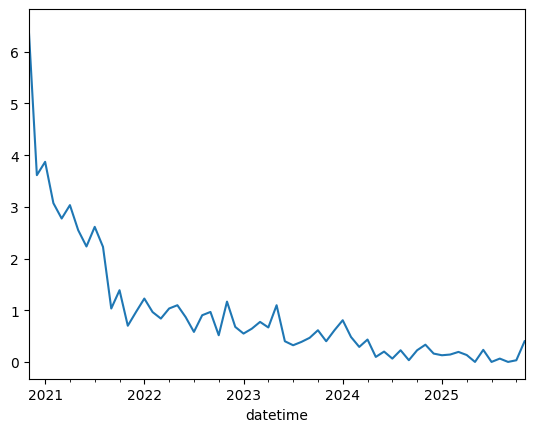

In [7]:
(df_merged.groupby(pd.PeriodIndex(df_merged['datetime'], freq="M"))['nwords_mw'].mean()).plot()

<Axes: xlabel='datetime'>

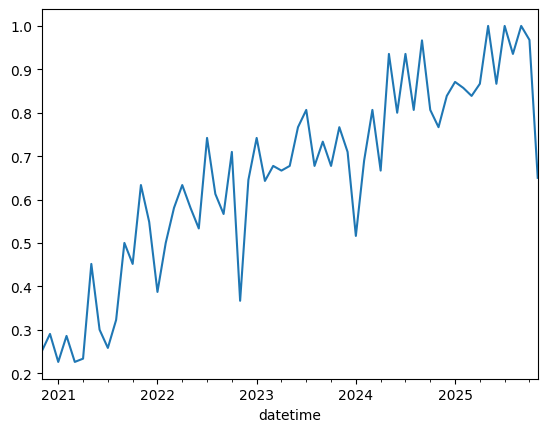

In [8]:
df_merged.groupby(pd.PeriodIndex(df_merged['datetime'], freq="M"))['qb'].mean().plot()

<Axes: xlabel='nwords_db'>

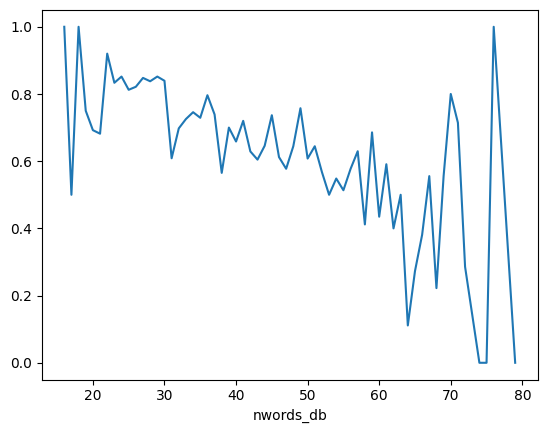

In [9]:
df_merged.groupby(df_merged['nwords_db'])['qb'].mean().plot()

<Axes: xlabel='nwords_db'>

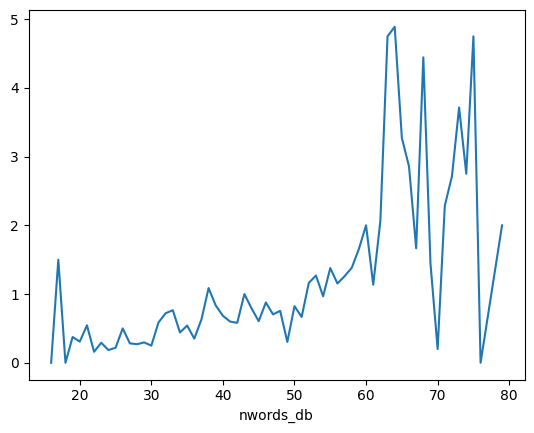

In [10]:
df_merged.groupby(df_merged['nwords_db'])['nwords_mw'].mean().plot()

<Axes: xlabel='datetime'>

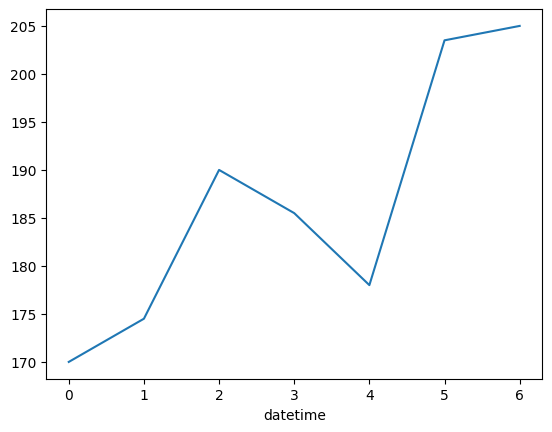

In [11]:
df_merged.groupby(df_merged['datetime'].dt.dayofweek)['points_db'].median().plot()


### Plots to make:

- restrict analyses above by date and notes presence
- solution rate or missed words as a function of number of words in the puzzle
- solution rate or missed words as a function of the number of points in the puzzle


### More Analysis:

- what are my worst alphagrams, i.e. for my most recently missed words, what are the alphagrams and what are the words that go with that alphagram?

In [12]:
from collections import Counter
# very simple: find the most recent of every alphagram occurance
all_alphagrams = {}
missed_counter = Counter()
found_counter = Counter()
for _,row in df_merged.iterrows():
    for k,v in row['alpha_dict_db'].items():
        all_alphagrams[k] = v
    if row['datetime']>=datetime(datetime.today().year-2,month=datetime.today().month,day=datetime.today().day):
        missed_words = [w for w in row['solution_mw'].split(' ') if len(w)>0]
        found_words = [w for w in row['solution_db'].split(' ') if len(w)>0 and w not in missed_words]
        missed_counter.update(missed_words)
        found_counter.update(found_words)


In [13]:
missed_counter.most_common()

[('CARIOCA', 2),
 ('ANYHOO', 2),
 ('ALLELE', 2),
 ('NANKEEN', 2),
 ('TINCT', 2),
 ('FAUCET', 2),
 ('LETTUCE', 2),
 ('MORATORIA', 1),
 ('TAMARI', 1),
 ('TRAITOR', 1),
 ('ETOUFFEE', 1),
 ('CONFIT', 1),
 ('TINFOIL', 1),
 ('OTOLOGY', 1),
 ('TELEOLOGY', 1),
 ('UNDULY', 1),
 ('UNRULY', 1),
 ('YUAN', 1),
 ('ANEMIA', 1),
 ('IMAGINING', 1),
 ('BOCCE', 1),
 ('OCARINA', 1),
 ('DUODENUM', 1),
 ('ODDMENT', 1),
 ('ODEUM', 1),
 ('TENEMENT', 1),
 ('HYMNARY', 1),
 ('LIPOMA', 1),
 ('PAPILLOMA', 1),
 ('TAILLAMP', 1),
 ('CLICHE', 1),
 ('BOOKRACK', 1),
 ('AGLEAM', 1),
 ('CATTILY', 1),
 ('TACTILITY', 1),
 ('LITTLENECK', 1),
 ('INDICA', 1),
 ('INDICIA', 1),
 ('POTHOOK', 1),
 ('APIAN', 1),
 ('NADIR', 1),
 ('NONPAID', 1),
 ('TITHING', 1),
 ('ARCANA', 1),
 ('CORNCOB', 1),
 ('ARCADIA', 1),
 ('AGELONG', 1),
 ('CETACEAN', 1),
 ('CHIVALRIC', 1),
 ('INVEIGLE', 1),
 ('VOILE', 1),
 ('CAVEAT', 1),
 ('FROUFROU', 1),
 ('BAAED', 1),
 ('BANDEAU', 1),
 ('BEDAUB', 1),
 ('BEDAUBED', 1),
 ('IRRIGATOR', 1),
 ('OTALGIA', 1),
 ('

In [14]:
data = [{'word':'hello','n':4},{'word':'goodbye','n':2}, {'word':'aloha','n':4}]

# Sort the data
sorted_data = sorted(data, key=lambda x: (-x['n'], x['word']))

print(sorted_data)

[{'word': 'aloha', 'n': 4}, {'word': 'hello', 'n': 4}, {'word': 'goodbye', 'n': 2}]


In [15]:
missed_word_practice_list = []
for item in missed_counter.most_common():
    word = item[0]
    missed = item[1]
    found = found_counter[word]
    alphagram = Word(word).alphagram()
    alpha = "\u03B1"
    if (found==0 or missed>=1) and word in all_alphagrams[Word(word).alphagram()]:
        d_word = {'word':word,'missed':missed,'found':found,'alphagram':alphagram,'alpha_len':len(alphagram),'alpha_list':all_alphagrams[alphagram],'l_alpha_list':len(all_alphagrams[alphagram])}
        missed_word_practice_list.append(d_word)
        print(f'Word: {word} Missed: {missed} Found: {found} \n {alpha} {alphagram}: {all_alphagrams[alphagram]} \n')

Word: CARIOCA Missed: 2 Found: 2 
 α ACIOR: ['CARIOCA'] 

Word: ANYHOO Missed: 2 Found: 2 
 α AHNOY: ['ANYHOO'] 

Word: ALLELE Missed: 2 Found: 20 
 α AEL: ['ALLELE'] 

Word: NANKEEN Missed: 2 Found: 5 
 α AEKN: ['NANKEEN'] 

Word: TINCT Missed: 2 Found: 24 
 α CINT: ['TINCT'] 

Word: FAUCET Missed: 2 Found: 0 
 α ACEFTU: ['EFFECTUATE', 'FAUCET'] 

Word: LETTUCE Missed: 2 Found: 2 
 α CELTU: ['CUTLET', 'CUTTLE', 'LETTUCE'] 

Word: MORATORIA Missed: 1 Found: 2 
 α AIMORT: ['IMITATOR', 'MORATORIA'] 

Word: TAMARI Missed: 1 Found: 4 
 α AIMRT: ['TAMARI'] 

Word: TRAITOR Missed: 1 Found: 5 
 α AIORT: ['ORATORIO', 'RATIO', 'TRAITOR', 'TRATTORIA'] 

Word: ETOUFFEE Missed: 1 Found: 2 
 α EFOTU: ['ETOUFFEE'] 

Word: CONFIT Missed: 1 Found: 4 
 α CFINOT: ['CONFIT', 'FICTION', 'NONFICTION'] 

Word: TINFOIL Missed: 1 Found: 0 
 α FILNOT: ['TINFOIL'] 

Word: OTOLOGY Missed: 1 Found: 2 
 α GLOTY: ['OTOLOGY'] 

Word: TELEOLOGY Missed: 1 Found: 2 
 α EGLOTY: ['TELEOLOGY'] 

Word: UNDULY Missed: 1 Fou

In [16]:
missed_word_practice_list = sorted(missed_word_practice_list, key=lambda x: (-x['missed'], x['alpha_len'], -x['l_alpha_list'], x['alphagram']))

missed_word_practice_list

[{'word': 'ALLELE',
  'missed': 2,
  'found': 20,
  'alphagram': 'AEL',
  'alpha_len': 3,
  'alpha_list': ['ALLELE'],
  'l_alpha_list': 1},
 {'word': 'NANKEEN',
  'missed': 2,
  'found': 5,
  'alphagram': 'AEKN',
  'alpha_len': 4,
  'alpha_list': ['NANKEEN'],
  'l_alpha_list': 1},
 {'word': 'TINCT',
  'missed': 2,
  'found': 24,
  'alphagram': 'CINT',
  'alpha_len': 4,
  'alpha_list': ['TINCT'],
  'l_alpha_list': 1},
 {'word': 'LETTUCE',
  'missed': 2,
  'found': 2,
  'alphagram': 'CELTU',
  'alpha_len': 5,
  'alpha_list': ['CUTLET', 'CUTTLE', 'LETTUCE'],
  'l_alpha_list': 3},
 {'word': 'CARIOCA',
  'missed': 2,
  'found': 2,
  'alphagram': 'ACIOR',
  'alpha_len': 5,
  'alpha_list': ['CARIOCA'],
  'l_alpha_list': 1},
 {'word': 'ANYHOO',
  'missed': 2,
  'found': 2,
  'alphagram': 'AHNOY',
  'alpha_len': 5,
  'alpha_list': ['ANYHOO'],
  'l_alpha_list': 1},
 {'word': 'FAUCET',
  'missed': 2,
  'found': 0,
  'alphagram': 'ACEFTU',
  'alpha_len': 6,
  'alpha_list': ['EFFECTUATE', 'FAUCET']

In [17]:
# now collect like alphagrams together in missed_word_practice_list
missed_word_practice_dict = {}
for word in missed_word_practice_list:
    alphagram = Word(word['word']).alphagram()
    if alphagram not in missed_word_practice_dict.keys():
        missed_word_practice_dict[alphagram] = {'missed_words':[word],
                                                'all_words':all_alphagrams[alphagram],
                                                }
    else:
        missed_word_practice_dict[alphagram]['missed_words'].append(word)
        
        

### Quiz

- separate singletons?
- give clues, including how many words you have left to guess
- clues start with tough words, length, then first letter
- use same machinery for singletons, but allow for a separate quiz for those


In [18]:
RED = '\033[91m'
BOLD = '\033[1m'
END = '\033[0m'
def clues(guess_count,d):
    words_remaining = [w for w in d['all_words'] if w not in d['all_found']]
    words_remaining.sort()
    clue_words = [f'{w[:guess_count]}{(len(w)-guess_count)*"."}' for w in words_remaining]
    return f'Clues: {clue_words}'


# def find_alphagram(w):
#     return ''.join(sorted(list(set(w.upper()))))

def guess_engine(alphagram,d):
    new_d = copy.deepcopy(d) 
    new_d['all_found'] = []
    new_d['missed_found'] = []
    guess = None
    guess_count = 0
    # TODO: as you miss more guesses, reveal more clues
    # you will have to keep track of guess_count in total rather than resetting every guess. 
    while guess!='XXX' and guess!='X' and guess_count<=4 and len(new_d["all_found"])<len(new_d["all_words"]):
        print(f'\n{BOLD}{RED}{alphagram}{END}\nYou have found these words, ALL: {new_d["all_found"]} left: {len(new_d["all_words"])-len(new_d["all_found"])}')
        print(f'You have found these words, MISSED: {new_d["missed_found"]} left: {len(new_d["missed_words"])-len(new_d["missed_found"])}')
        if guess_count>0:
            print(clues(guess_count,new_d))
        guess = input(f'--> Guess any word for {BOLD}{RED}{alphagram}{END}: X to exit word, XXX to exit quiz:  ').upper()
        if guess in new_d['missed_words'] and guess not in new_d['missed_found']:
            new_d['all_found'].append(guess)
            new_d['missed_found'].append(guess)
            print(f'Nice! You found a tough word: {guess}')
        elif guess in new_d['all_words'] and guess not in new_d['all_found']:
            new_d['all_found'].append(guess)
            print(f'Nice! You found a word: {guess}')
        elif len(guess) <= BeeParameters.min_tiles:
            print('Guess has too few letters!')
            guess_count += 1
        elif guess == 'XXX':
            return 'XXX'
        elif guess == 'X':
            print(new_d)
            return None
        elif Word(guess).alphagram() != alphagram:
            print(f'Your guess: {guess} alphagram: {Word(guess).alphagram()} does not match the letters {alphagram}')
            guess_count += 1
        else:
            print('Try again!')
            guess_count += 1
            # put a check here to reveal the answer if you are at the end of guesses
            if guess_count > 4:
                print(new_d)
    return None


In [19]:
arand = [k for k in missed_word_practice_dict.keys()]
random.shuffle(arand)
for i,a in enumerate(arand):
    print(f'word {i+1} of {len(arand)} -----------------')
    if guess_engine(a,missed_word_practice_dict[a]) == 'XXX':
        break
    else:
        pass

word 1 of 145 -----------------

AILMPT
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for AILMPT: X to exit word, XXX to exit quiz:  taillamp
Nice! You found a word: TAILLAMP
word 2 of 145 -----------------

AFINT
You have found these words, ALL: [] left: 4
You have found these words, MISSED: [] left: 1
--> Guess any word for AFINT: X to exit word, XXX to exit quiz:  faint
Nice! You found a word: FAINT

AFINT
You have found these words, ALL: ['FAINT'] left: 3
You have found these words, MISSED: [] left: 1
--> Guess any word for AFINT: X to exit word, XXX to exit quiz:  affiant
Nice! You found a word: AFFIANT

AFINT
You have found these words, ALL: ['FAINT', 'AFFIANT'] left: 2
You have found these words, MISSED: [] left: 1
--> Guess any word for AFINT: X to exit word, XXX to exit quiz:  infant
Nice! You found a word: INFANT

AFINT
You have found these words, ALL: ['FAINT', 'AFFIANT', 'INFANT'] left: 1
You have found these w

Guess has too few letters!
word 24 of 145 -----------------

GINOPU
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for GINOPU: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 25 of 145 -----------------

BCNOR
You have found these words, ALL: [] left: 3
You have found these words, MISSED: [] left: 1
--> Guess any word for BCNOR: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 26 of 145 -----------------

BIKLNO
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for BIKLNO: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 27 of 145 -----------------

ACLORTU
You have found these words, ALL: [] left: 2
You have found these words, MISSED: [] left: 1
--> Guess any word for ACLORTU: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 28 of 145 -----------------

ABLORT
You have found these wor

--> Guess any word for ACELT: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 59 of 145 -----------------

ABGIT
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for ABGIT: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 60 of 145 -----------------

EILOV
You have found these words, ALL: [] left: 2
You have found these words, MISSED: [] left: 1
--> Guess any word for EILOV: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 61 of 145 -----------------

AEL
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for AEL: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 62 of 145 -----------------

BDIT
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for BDIT: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 63 of 1

--> Guess any word for CIRT: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 94 of 145 -----------------

AILNO
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for AILNO: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 95 of 145 -----------------

ALNOPV
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for ALNOPV: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 96 of 145 -----------------

ANUY
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for ANUY: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 97 of 145 -----------------

CEHLY
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for CEHLY: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 98

Guess has too few letters!
word 128 of 145 -----------------

ACDNO
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for ACDNO: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 129 of 145 -----------------

ADINOP
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for ADINOP: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 130 of 145 -----------------

EIKLP
You have found these words, ALL: [] left: 1
You have found these words, MISSED: [] left: 1
--> Guess any word for EIKLP: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 131 of 145 -----------------

DENOY
You have found these words, ALL: [] left: 2
You have found these words, MISSED: [] left: 1
--> Guess any word for DENOY: X to exit word, XXX to exit quiz:  X
Guess has too few letters!
word 132 of 145 -----------------

AGHILRT
You have found these wor

## Code Graveyard

In [ ]:

singletons = [k for k,v in missed_counter.items() if (found_counter[k]<=missed_counter[k] and len(all_alphagrams[Word(k).alphagram()])==1 and k in all_alphagrams[Word(k).alphagram()])]      # current word
random.shuffle(singletons)
for k in singletons:
    guess = None
    guess_count = 0
    while guess != all_alphagrams[Word(k).alphagram()][0] and guess != 'XXX' and guess != 'X' and guess_count <=4:
        guess = input(f'Word up - X to exit word, XXX to exit quiz: {Word(k).alphagram()}  ').upper()
        guess_count += 1
    print(f'{Word(k).alphagram()}:{all_alphagrams[Word(k).alphagram()]}')
    if guess == 'XXX':
        break

## Evan's ask: wasn't this word missing before?

In [61]:
# def word_history(word,df,verbose=True):
#     w = Word(word)
#     last_valid=None
#     counter = 0
#     for index, row in df.iterrows():
#         puzzle_tiles = row['tiles']
#         if w.validinpuzzle(puzzle_tiles):
#             solution_list = row['solution'].split(' ')
#             if w.string() in solution_list:
#                 disp_text = '.'
#                 if last_valid is None or not last_valid or verbose:
#                     print(f"Word {w} matches puzzle {puzzle_tiles} on date {row['date']} {disp_text}")
#                 last_valid=True
#             else:
#                 disp_text = 'Not in solution'
#                 if last_valid is None or last_valid or verbose:
#                     print(f"Word {w} matches puzzle {puzzle_tiles} on date {row['date']} {disp_text}")
#                 last_valid=False
#                 #TODO: put in counter


# word = 'raffia'
# word_history(word,df_db,verbose=True)

In [18]:
def word_history(word, df, verbose=True):
    w = Word(word)
    last_valid = None
    counter = 0
    first_time = True

    for index, row in df.iterrows():
        puzzle_tiles = row['tiles']
        if w.validinpuzzle(puzzle_tiles):
            solution_list = row['solution'].split(' ')
            current_valid = w.string() in solution_list
            disp_text = '.' if current_valid else 'Not in solution'

            if first_time or last_valid is None or last_valid != current_valid or verbose:
                if not first_time and not verbose:
                    print(f"Word {w} matches puzzle {puzzle_tiles} on date {row['date']} {disp_text} (count: {counter})")
                print(f"Word {w} matches puzzle {puzzle_tiles} on date {row['date']} {disp_text}")
                counter = 1
            else:
                counter += 1

            last_valid = current_valid
            first_time = False

    if not verbose and counter > 1:
        print(f"Word {w} matches puzzle {puzzle_tiles} on date {row['date']} {disp_text} (count: {counter})")

# Example usage
word = 'figgy'
word_history(word, df_db, verbose=True)

Word FIGGY matches puzzle FGILORY on date 2018-09-19 Not in solution
Word FIGGY matches puzzle FAGIRTY on date 2018-11-13 Not in solution
Word FIGGY matches puzzle GFILORY on date 2019-05-19 Not in solution
Word FIGGY matches puzzle GFILORY on date 2020-10-06 Not in solution
Word FIGGY matches puzzle IDEFGNY on date 2021-08-28 Not in solution
Word FIGGY matches puzzle IDEFGTY on date 2022-01-13 Not in solution
Word FIGGY matches puzzle YAFGIRT on date 2022-08-08 Not in solution
Word FIGGY matches puzzle FDEGITY on date 2024-01-09 .
Word FIGGY matches puzzle IFGHLTY on date 2024-02-21 .
Word FIGGY matches puzzle GFILNVY on date 2024-09-29 .



## Code Graveyard

In [ ]:
mw_google_sheet.merge_missing_words_with_db(df_db=db_google_sheet.df)
# df = db_google_sheet.df.merge(mw_google_sheet.df,how='inner',on='date')
self.df_merged = df_db.merge(self.df,how='inner',on=MissedWords_Parameters.date,suffixes=('_db', '_mw'))
self.df_merged[MissedWords_Parameters.unmatched_words] = self.df_merged.apply(lambda x: unmatched_words(x, col_label_wordset=MissedWords_Parameters.solution+'_db', col_label_wordsubset=MissedWords_Parameters.solution+'_mw'), axis=1)


In [ ]:
mw_google_sheet.df_merged['unmatched words']

In [ ]:
# mw_google_sheet.validate_missing_words_versus_db(db_google_sheet)

In [ ]:
mw_google_sheet.df_merged



In [30]:
from datetime import datetime, timedelta
date='2024-09-18'
# datetime()